# Step 2 — Novel-view rendering (mesh geometry + optional splat RGB)

**Prerequisites:** `data/sample.glb` **or** a SAM3D run: set `SAM3D_RUN_DIR` in the next cell to the same `RUN_DIR` as `10_sam3d_from_gsplat.ipynb` (folder that contains `reconstruction/mesh.glb`). Default config uses `rendering.backend: gaussian` (splat RGB when `splat_path` is valid); `mesh` forces mesh-colour RGB.

**Camera policy:** orbit pitch is intersected with **`[25°, 60°]`** above the ground plane (no flat-horizon views; looks down at the asset).

**Geometry aux (default):** each view may include **`normal_{i}.npy`** (world normals as RGB) and **`depth_vis_{i}.npy`** (depth as 3-channel uint8) for SAM / muddy splat RGB — set `rendering.render_geometry_aux: false` to skip.

**Pass checklist (last cell):**
- All views have non-trivial RGB
- Depth maps differ across views
- ≥10% vertices visible in at least one view
- Visible points cover many image rows/columns (not one horizontal band)

After updating `mesh_renderer.py`, delete `outputs/notebooks/02_rendering/` and re-run this notebook, then **04** (VLM) and **05** (projection). For gsplat-only exploration, run **`03_rendering_gaussian_splat.ipynb`**.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from datasets.mesh_loading import load_mesh, normalize_mesh
from rendering.renderer import render_mesh_views
from utils.config import load_config, resolve_path

In [2]:
cfg = load_config()

# Optional: wire SAM3D outputs from notebook 10 — same RUN_DIR (parent of reconstruction/).
SAM3D_RUN_DIR: Path | None = None  # e.g. ROOT / "exports" / "gsplat_sam3d_runs" / "demo_gsplat_sam3d"
if SAM3D_RUN_DIR is not None:
    from reconstruction.mesh_utils import cfg_with_sam3d_reconstruction

    cfg = cfg_with_sam3d_reconstruction(cfg, SAM3D_RUN_DIR)

assert cfg["rendering"]["backend"] in ("mesh", "gaussian", "both"), (
    "Unsupported rendering.backend — use mesh, gaussian, or both"
)

mesh_path = resolve_path(cfg["rendering"]["mesh_path"])
mesh = normalize_mesh(load_mesh(mesh_path))
print(f"mesh {mesh.num_vertices} verts, {mesh.num_faces} faces")

cache_dir = ROOT / "outputs" / "notebooks" / "02_rendering"
cache_dir.mkdir(parents=True, exist_ok=True)

views = render_mesh_views(mesh, cfg)
print(f"rendered {len(views)} views @ {views[0].rgb.shape[0]}px")

mesh 5328 verts, 9499 faces
rendered 6 views @ 512px


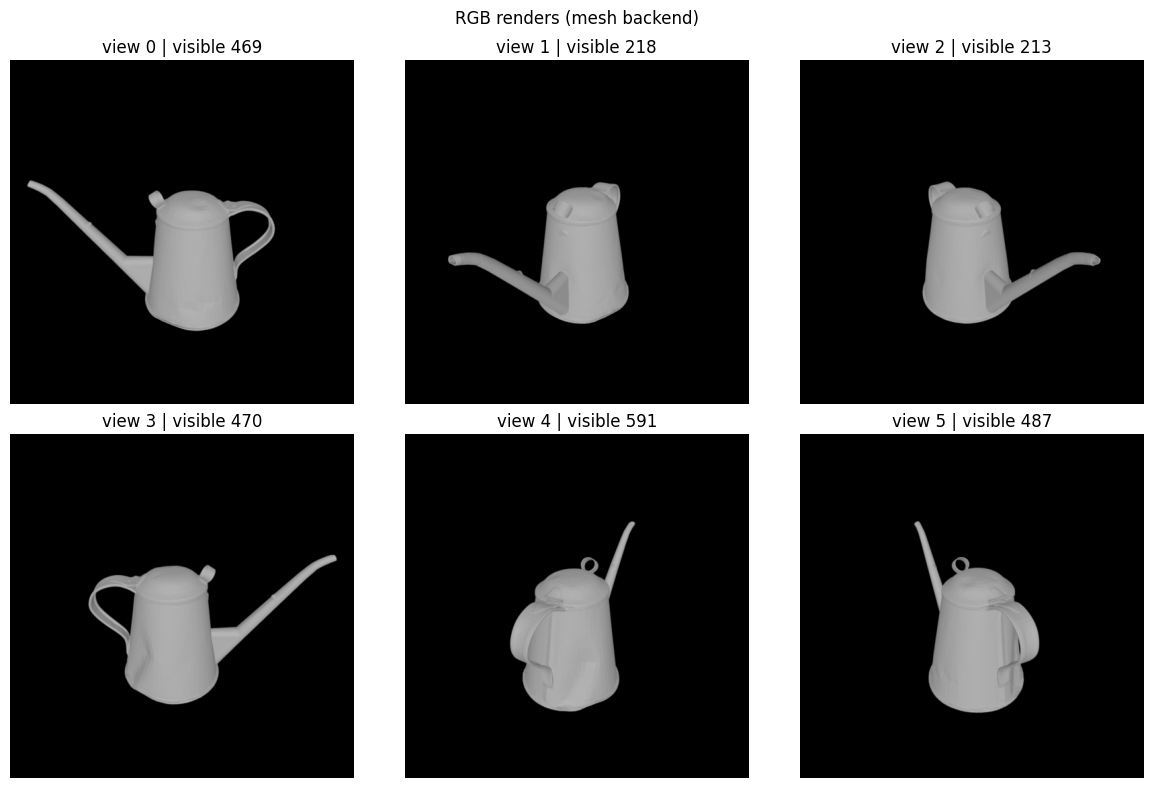

In [3]:
ncols = min(3, len(views))
nrows = int(np.ceil(len(views) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).ravel()
for i, view in enumerate(views):
    axes[i].imshow(view.rgb)
    vis = view.vertex_visible.sum()
    axes[i].set_title(f"view {i} | visible {vis}")
    axes[i].axis("off")
for j in range(len(views), len(axes)):
    axes[j].axis("off")
fig.suptitle("RGB renders (config rendering.backend)")
plt.tight_layout()
plt.show()

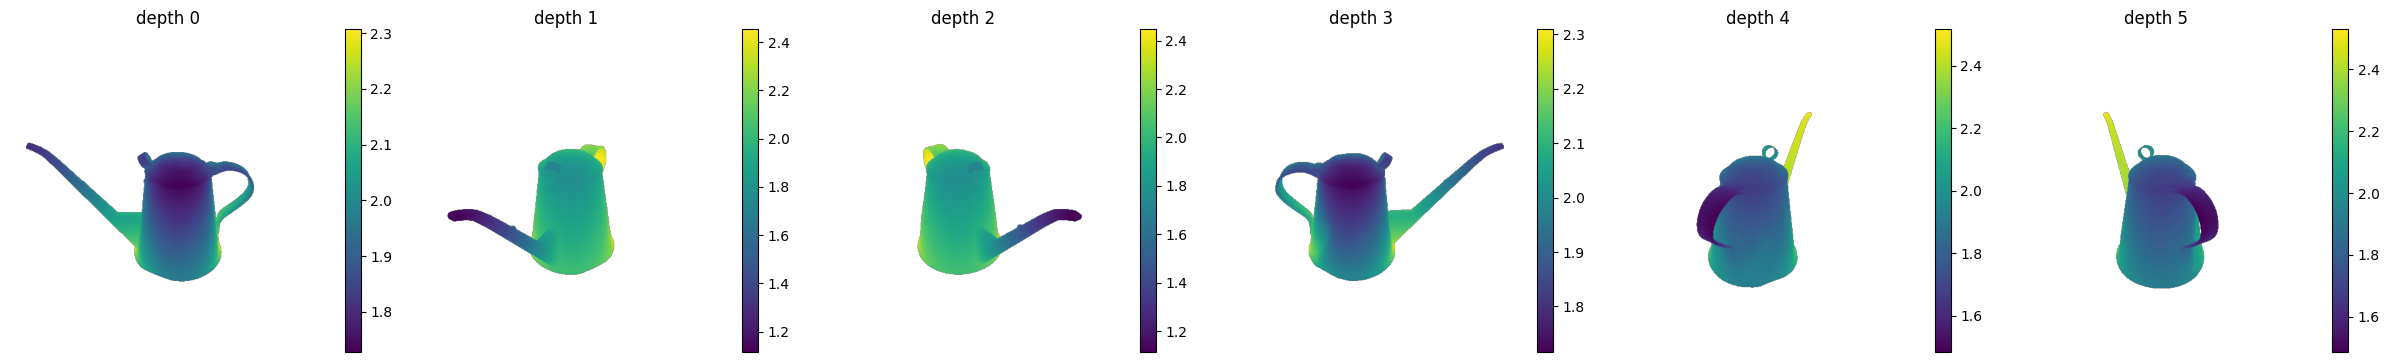

In [4]:
fig, axes = plt.subplots(1, len(views), figsize=(4 * len(views), 4))
if len(views) == 1:
    axes = [axes]
for i, view in enumerate(views):
    d = view.depth.copy()
    d[d <= 0] = np.nan
    im = axes[i].imshow(d, cmap="viridis")
    axes[i].set_title(f"depth {i}")
    axes[i].axis("off")
    fig.colorbar(im, ax=axes[i], fraction=0.046)
plt.tight_layout()
plt.show()

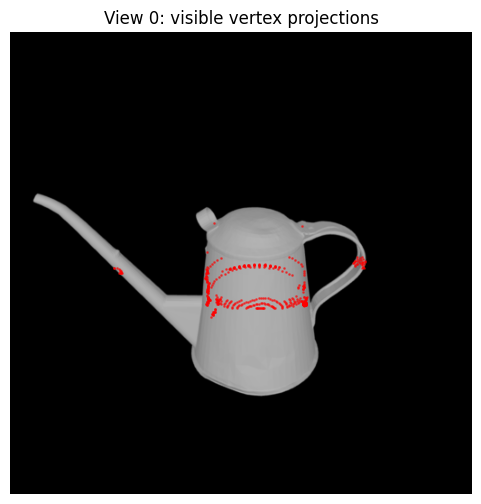

vertices visible in >=1 view: 32.3%


In [5]:
view = views[0]
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(view.rgb)
uv = view.vertex_uv[view.vertex_visible]
ax.scatter(uv[:, 0], uv[:, 1], s=1, c="red", alpha=0.5)
ax.set_title("View 0: visible vertex projections")
ax.axis("off")
plt.show()

any_visible = np.stack([v.vertex_visible for v in views], axis=0).any(axis=0)
frac = any_visible.mean()
print(f"vertices visible in >=1 view: {frac:.1%}")

In [6]:
for i, view in enumerate(views):
    np.save(cache_dir / f"rgb_{i}.npy", view.rgb)
    np.save(cache_dir / f"depth_{i}.npy", view.depth)
    np.save(cache_dir / f"vertex_uv_{i}.npy", view.vertex_uv)
    np.save(cache_dir / f"vertex_visible_{i}.npy", view.vertex_visible)
    if view.normal_rgb is not None:
        np.save(cache_dir / f"normal_{i}.npy", view.normal_rgb)
    if view.depth_vis_rgb is not None:
        np.save(cache_dir / f"depth_vis_{i}.npy", view.depth_vis_rgb)
print("cached to", cache_dir)

cached to /Users/mattiskrauch/Documents/Studium/Semester 4/ADL4CV/affordance-prediction/outputs/notebooks/02_rendering


In [7]:
h, w = views[0].rgb.shape[:2]
for i, view in enumerate(views):
    assert view.rgb.shape == (h, w, 3)
    assert view.rgb.mean() > 5, f"view {i} looks blank"
    assert view.vertex_visible.sum() > 0
    uv = view.vertex_uv[view.vertex_visible]
    assert (uv[:, 0] >= 0).all() and (uv[:, 0] < w).all()
    assert (uv[:, 1] >= 0).all() and (uv[:, 1] < h).all()
    if view.normal_rgb is not None:
        assert view.normal_rgb.shape == (h, w, 3)
    if view.depth_vis_rgb is not None:
        assert view.depth_vis_rgb.shape == (h, w, 3)

depth_means = [v.depth[v.depth > 0].mean() for v in views if (v.depth > 0).any()]
assert len(set(np.round(depth_means, 3))) > 1, "depth should change across views"

assert frac >= 0.10, f"too few visible vertices: {frac:.1%}"

vis_rows = np.unique(np.round(view.vertex_uv[view.vertex_visible, 1]).astype(int))
assert len(vis_rows) > 20, f"visible vertices span only {len(vis_rows)} rows — check mesh_renderer"

print("PASS: Step 2 mesh rendering")

PASS: Step 2 mesh rendering
